# Mini Project 2

By the deadline, please submit the provided Jupyter notebook with all/some required tasks completed and clearly solved. Make sure your code is neat, well-commented, and that all outputs are visible (run all cells before saving). Notebooks with missing tasks or unexecuted cells may receive fewer points. After you submit, you won’t be able to make changes, so double-check your work and be sure to start from the provided template

## Submission rules
As already discussed in class, we will stick to the following rules.
- Use the templates and name your files `NAME_SURNAME.ipynb` (If you have more than one name, just concatenate them). We will compare what you present with that file. 
- Code either not written in Python or not using PyTorch receives a grade of 0. Of course, you can use auxiliary packages when needed (`matplotlib`, `numpy`, ...), but for the learning part, you must use PyTorch.
-  If plagiarism is suspected, TAs and I will thoroughly investigate the situation, and we will summon the student for a face-to-face clarification regarding certain answers they provided. In case of plagiarism, a score reduction will be applied to all the people involved, depending on their level of involvement.
-  If extensive usage of AI tools is detected, we will summon the student for a face-to-face clarification regarding certain answers they provided. If the answers are not adequately supported with in-person answers, we will proceed to apply a penalty to the evaluation, ranging from 10% to 100%.

In [1]:
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch
from torch.utils.data import DataLoader

## Image classification uning a CNN

The CIFAR-10 dataset is a widely used collection of images in the field of computer vision. It consists of 60000 (50000 for the training and 10000 for the test) 32x32 color images across 10 different classes, with each class containing 6,000 images. These classes include common objects such as airplanes, automobiles, cats, and dogs. CIFAR-10 serves as a benchmark for image classification tasks and has been instrumental in developing and evaluating machine learning algorithms for image recognition. 
The task of this assignment is to classify the images

### Task 0 (0 pts)
Understand what's going on in the two cells below. Do the following experiments: 
1. Run the first and the second cell in a row.
2. Run the first cell and two times in a row the second one.

What do you observe? We don't need any answer, but please just keep this phenomenon in mind. 

In [2]:
torch.manual_seed(0)

In [3]:
torch.randint(1, 10 , (1,1))

tensor([[9]])

Now, we'll set a seed that will remain the same for all the code below

### Task 1 (2.5 pts)
Load the [data (You can do it directly in PyTorch)](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html) and take some time to inspect the dataset. Report here at least one image per class and a histogram of the distribution of the images of the training and test set. 

In [4]:
# download training data
dataset_train = torchvision.datasets.CIFAR10('./cifar10', train=True, download=True)
dataset_test = torchvision.datasets.CIFAR10('./cifar10', train=False, download=True)

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./cifar10
    Split: Train
(<PIL.Image.Image image mode=RGB size=32x32 at 0x7C1E74263650>, 6)
Classes:  ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
There are 50000 for training and 10000 for testing.


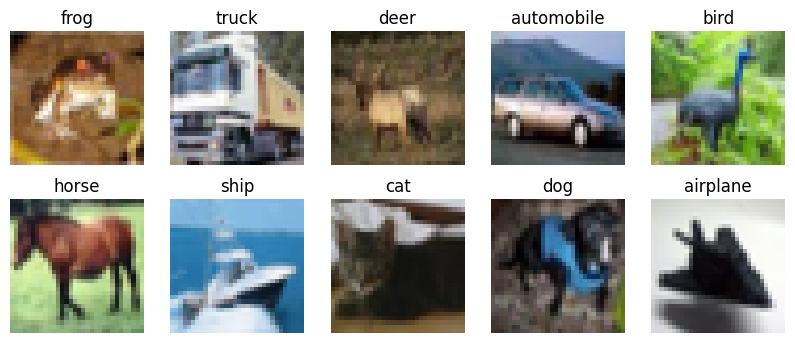

In [5]:
# print basic information
print(dataset_train)
print(dataset_train[0])
print("Classes: ", dataset_train.classes)
print(f"There are {len(dataset_train)} for training and {len(dataset_test)} for testing.")

# get one image of each class
samples = {}
for img, label in dataset_train:
    if label not in samples:
        samples[label] = img
    if len(samples) == len(dataset_train.classes):
        break

# show images with corresponding label
fig, axs = plt.subplots(2, len(dataset_train.classes)//2)
for ax, label_ix, img in zip(axs.flatten(), samples.keys(), samples.values()):
    ax.imshow(img)
    ax.set_title(dataset_train.classes[label_ix])
    ax.set_axis_off()

fig.set_size_inches(10, 4)
plt.show()

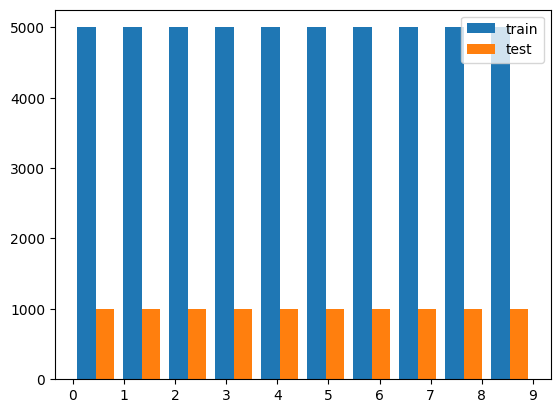

In [6]:
# display histogram of training and test dataset
get_labels = lambda dataset: [data[1] for data in dataset]
bins = len(dataset_train.classes)
plt.hist([get_labels(dataset_train), get_labels(dataset_test)], label=['train', 'test'])
plt.legend(loc='best')
plt.xticks(range(len(dataset_train.classes)))
plt.show()

### Task 2 (2.5 pts)
Are the entries in the correct type for the DL framework in PyTorch? How can you arrive at a suitable format for your training pipeline? Be sure to have understood
- The type of each element of the dataset 
- How we can convert it to a suitable type.
- The dimension of the image as a `torch.Tensor` object
- The meaning of each dimension of the images 

In [7]:
# add transformer to datasets to get images as tensors
dataset_train.transform = transforms.ToTensor()
dataset_test.transform = transforms.ToTensor()

### Task 3 (10 pts)
When you arrive at this question you should have each entry as a `torch.Tensor` of shape (3,32, 32) and clear the meaning of each dimension. A good practice in DL is to work with features having mean 0 and standard deviation equal to 1. Convert the dataset of the images in this format. To do so, you can do it from scratch (not recommended) or use the function [`torchvision.transforms.Normalize`](https://pytorch.org/vision/0.8/transforms.html\#torchvision.transforms.Normalize). If you go for this second option, don't forget that we have already transformed our dataset in the previous point, hence, it could be of help using the function [`transforms.Compose`](https://pytorch.org/vision/0.8/transforms.html\#torchvision.transforms.Compose). You can see an example in the tutorial linked above.

**Note** that the usage of the function is tricky: try to really understand what's going on

In [8]:
# calculate std and mean of each channel
def get_std_mean(dataset, batch_size=None):
    batch_size = batch_size if batch_size else len(dataset_test)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size)
    all_images = next(iter(loader))[0]
    return torch.std_mean(all_images, dim=[0, 2, 3])

In [9]:
stds_train, means_train = get_std_mean(dataset_train)
stds_test, means_test = get_std_mean(dataset_test)
print("Calculated mean train:", means_train)
print("Calculated std train:", stds_train)

Calculated mean train: tensor([0.4935, 0.4834, 0.4472])
Calculated std train: tensor([0.2476, 0.2446, 0.2626])


In [10]:
# update transform to include normalization with computed means/stds
dataset_train.transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize(means_train, stds_train)]
)
dataset_test.transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize(means_test, stds_test)]
)

print("shape: ", dataset_train[0][0].shape, "dtype: ", dataset_train[0][0].dtype)

shape:  torch.Size([3, 32, 32]) dtype:  torch.float32


In [11]:
# Recalculate mean and std after normalization to verify
stds, means = get_std_mean(dataset_train, batch_size=5000)
print("Mean after normalization (should be ~0):", means)
print("Std after normalization (should be ~1):", stds)

Mean after normalization (should be ~0): tensor([-0.0089, -0.0080, -0.0103])
Std after normalization (should be ~1): tensor([0.9999, 0.9996, 1.0005])


### Task 4 (1 pts)
As you might have observed, we only have a train and test set. We need a validation set for hyperparameter tuning. Create a validation set by splitting the test set. 

In [12]:
dataset_validation, dataset_test = torch.utils.data.random_split(dataset_test, [0.5, 0.5])

### Task 5 (20 pts)
Starting from the code provided during Lecture 6, define a ConvNet. You can **only** use:

- Convolutional layers  
- Max/Avg Pooling layers  
- Activation Functions  
- Fully connected layers  

Note that the choice `Conv - Pool - Conv` is not mandatory. Have you tried `Conv - Conv - Activ - Pool - Conv - Conv - Activ - Pool - FC`?  
For each convolutional layer you can choose padding and stride. Be prepared on comment on the choices of the dimensions of the layers.

In [13]:
from math import floor

def out_dimensions(conv_layer, h_in, w_in):
    '''
    This function computes the output dimension of each convolutional layers in the most general way. 
    See here https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
    '''
    h_out = floor((h_in + 2 * conv_layer.padding[0] - conv_layer.dilation[0] * (conv_layer.kernel_size[0] - 1) - 1) /
                  conv_layer.stride[0] + 1)
    w_out = floor((w_in + 2 * conv_layer.padding[1] - conv_layer.dilation[1] * (conv_layer.kernel_size[1] - 1) - 1) /
                  conv_layer.stride[1] + 1)
    return h_out, w_out

class Model_OG(nn.Module):
    def __init__(self, channels=3, height=32, width=32):
        super().__init__()
        
        conv1 = nn.Conv2d(channels, 32, kernel_size=5, padding=2)
        h_out, w_out = out_dimensions(conv1, height, width)
        pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        h_out, w_out = h_out // 2, w_out // 2
        conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        h_out, w_out = out_dimensions(conv2, h_out, w_out)
        pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        h_out, w_out = h_out // 2, w_out // 2
        
        conv3 = nn.Conv2d(32, 20, kernel_size=3, padding=1)
        h_out, w_out = out_dimensions(conv3, h_out, w_out)
        pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        h_out, w_out = h_out // 2, w_out // 2
        
        self.conv_seq = nn.Sequential(conv1, pool1, nn.ReLU(), conv2, pool2, nn.ReLU(), conv3, pool3, nn.ReLU())
        
        self.fc1 = nn.Linear(20 * h_out * w_out, out_features=120)
        self.fc2 = nn.Linear(120, out_features=10)
        
        self.dimensions_final = (20, h_out, w_out)
        
    def forward(self, x):
        x = self.conv_seq(x)
        
        n_channels, h, w = self.dimensions_final
        x = x.view(-1, n_channels * h * w)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

print(Model_OG(3, 32))
print(Model_OG(3, 32).dimensions_final)

Model_OG(
  (conv_seq): Sequential(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (5): ReLU()
    (6): Conv2d(32, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): ReLU()
  )
  (fc1): Linear(in_features=320, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=10, bias=True)
)
(20, 4, 4)


### Task 6 (35 pts)
Implement the training pipeline. Make sure to code the following:

- Print and record the current training loss and accuracy every *n* steps (choose *n*)  
- Print and record the current validation loss and accuracy every *n* steps (choose *n*)  

The validation loss will help you in hyperparameter tuning. Train your model.  
With my choice of hyperparameters, the best test accuracy is above **65%**, hence, a necessary condition to get full marks is to achieve an accuracy on the test set greater or equal to **65%**.

You may want to follow some of these hints (**They are, of course, dependent on the architecture, optimizer, ...**):

- 5 epochs should be enough  
- Batch size = 32 could be a good starting point  
- A learning rate around 0.03 should be a good tradeoff between speed and stability  
- SGD should be a good optimizer  

Be prepared to answer the following questions:
- Why that learning rate? Why not higher/smaller?  
- Number of epochs: Why that number?  
- Some comments on your architecture: why that deep? why not deeper? why not smaller?  

In [14]:
import copy

class EarlyStopping():
    def __init__(self, patience=5, min_delta=0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta # minimum improvement to reset patience
        self.restore_best_weights = restore_best_weights
        self.best_model = None
        self.best_loss = None
        self.counter = 0
        self.status = ""
        
    def __call__(self, model, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model = copy.deepcopy(model)
        elif self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_model.load_state_dict(model.state_dict())
        elif self.best_loss - val_loss < self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.status = f"Stopped on {self.counter}"
                if self.restore_best_weights:
                    model.load_state_dict(self.best_model.state_dict())
                return True
        self.status = f"{self.counter}/{self.patience}"
        return False

In [15]:
model = Model_OG(3, 32)
early_stop = EarlyStopping(patience=10, min_delta=0.01)
learning_rate = 0.03
batch_size = 32
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()
print(model.dimensions_final)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'mps' 
    if torch.backends.mps.is_available() else 'cpu')
model = model.to(DEVICE)
print("Working on", DEVICE)

(20, 4, 4)
Working on cuda


In [16]:
train_loader = DataLoader(dataset_train, batch_size=batch_size, pin_memory=True, num_workers=2)
validation_loader = DataLoader(dataset_validation, batch_size=len(dataset_validation), pin_memory=True, num_workers=2)
test_loader = DataLoader(dataset_test, batch_size=len(dataset_test), pin_memory=True, num_workers=2)

In [17]:
def evaluate_model(model, data_loader, loss_fn):
    model.eval()
    total_loss = 0
    n_correct = 0
    n_samples = 0
    
    for data, target in data_loader: # Just one batch
            data, target = data.to(DEVICE), target.to(DEVICE)
            # Make a prediction
            output = model(data)
            # Compute the loss function
            total_loss += loss_fn(output, target).item()
            # Compute the accuracy
            _, predicted = torch.max(output.data, 1)
            n_samples += target.size(0)
            n_correct += (predicted == target).sum().item()
        
    avg_loss = total_loss / len(data_loader)
    accuracy = 100.0 * n_correct / n_samples
    return avg_loss, accuracy

    

In [18]:
def fit(model, epochs=5, logging_interval=250):
    train_loss_list = []
    train_acc_list = []
    val_loss_list = []
    val_acc_list = []
    for epoch in range(epochs):
        n_correct = 0
        n_samples = 0
        loss_train = 0
        for step, (data, target) in enumerate(train_loader):
            # Set the model in training mode
            model.train()
            data, target = data.to(DEVICE), target.to(DEVICE)
            # Set the gradient to 0
            optimizer.zero_grad()
            # Make a prediction
            output = model(data)
            # Compute the loss function
            loss = loss_fn(output, target)
            loss_train += loss.item()
            # Backpropagation
            loss.backward()
            # Update parameters
            optimizer.step()
            # Compute the training accuracy
            _, predicted = torch.max(output.data, 1)
            n_samples += target.size(0)
            n_correct += (predicted == target).sum().item()
            # Log every logging_interval steps train and validation loss and accuracy
            if (step + 1) % logging_interval == 0:
                # Calculate avg train loss and acc over last steps
                avg_loss_train = loss_train / logging_interval
                avg_train_acc = 100.0 * n_correct / n_samples
                # Validate
                val_loss, val_acc = evaluate_model(model, validation_loader, loss_fn)
                
                print(f"Epoch {epoch+1}, Step {step+1}: " 
                    f"Training Loss: {avg_loss_train:.4f}, Training Accuracy: {avg_train_acc:.2f}% | "
                    f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.2f}%")
                
                train_loss_list.append(avg_loss_train)
                train_acc_list.append(avg_train_acc)
                val_loss_list.append(val_loss)
                val_acc_list.append(val_acc)
                # Reset
                loss_train, n_samples, n_correct = 0, 0, 0
                
                    # Early stopping check
                if early_stop(model, val_loss):
                    print(f"Stopped trained at epoch {epoch}")
                    break
                
        # Log remaining batches
        remainder = (step + 1) % logging_interval
        if remainder != 0:
            avg_loss_train = loss_train / remainder
            avg_train_acc = 100.0 * n_correct / n_samples
            val_loss, val_acc = evaluate_model(model, validation_loader, loss_fn)
            
            print(f"Epoch {epoch+1}, Step {step+1}: "
                f"Train Loss: {avg_loss_train:.4f}, Train Acc: {avg_train_acc:.2f}% | "
                f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
            
            train_loss_list.append(avg_loss_train)
            train_acc_list.append(avg_train_acc)
            val_loss_list.append(val_loss)
            val_acc_list.append(val_acc)
        
    return model, train_loss_list, train_acc_list, val_loss_list, val_acc_list
    

In [19]:
# Final test evaluation
logging_interval = 250
model, train_loss_list, train_acc_list, val_loss_list, val_acc_list = fit(model, logging_interval=logging_interval)
_, test_acc = evaluate_model(model, test_loader, loss_fn)
print(f"\nTest Accuracy: {test_acc:.2f}%")

Epoch 1, Step 250: Training Loss: 2.1975, Training Accuracy: 18.09% | Val Loss: 2.0192, Val Accuracy: 25.22%
Epoch 1, Step 500: Training Loss: 1.9433, Training Accuracy: 29.62% | Val Loss: 1.8566, Val Accuracy: 32.80%
Epoch 1, Step 750: Training Loss: 1.7418, Training Accuracy: 36.90% | Val Loss: 1.6313, Val Accuracy: 40.82%
Epoch 1, Step 1000: Training Loss: 1.6265, Training Accuracy: 40.95% | Val Loss: 1.5647, Val Accuracy: 42.88%
Epoch 1, Step 1250: Training Loss: 1.5644, Training Accuracy: 43.55% | Val Loss: 1.5006, Val Accuracy: 45.12%
Epoch 1, Step 1500: Training Loss: 1.5082, Training Accuracy: 46.19% | Val Loss: 1.4208, Val Accuracy: 48.50%
Epoch 1, Step 1563: Train Loss: 1.4718, Train Acc: 48.40% | Val Loss: 1.5815, Val Acc: 41.58%
Epoch 2, Step 250: Training Loss: 1.4223, Training Accuracy: 48.79% | Val Loss: 1.3815, Val Accuracy: 50.58%
Epoch 2, Step 500: Training Loss: 1.4028, Training Accuracy: 49.59% | Val Loss: 1.3876, Val Accuracy: 50.08%
Epoch 2, Step 750: Training Los

### Task 7 (4 pts)
Plot the evolution of the training and validation losses on the same graph. On the x-axis, you should preferably use the number of steps. Do you observe signs of overfitting or underfitting? Note that an improperly trained model will also result in a point deduction for the previous exercise.

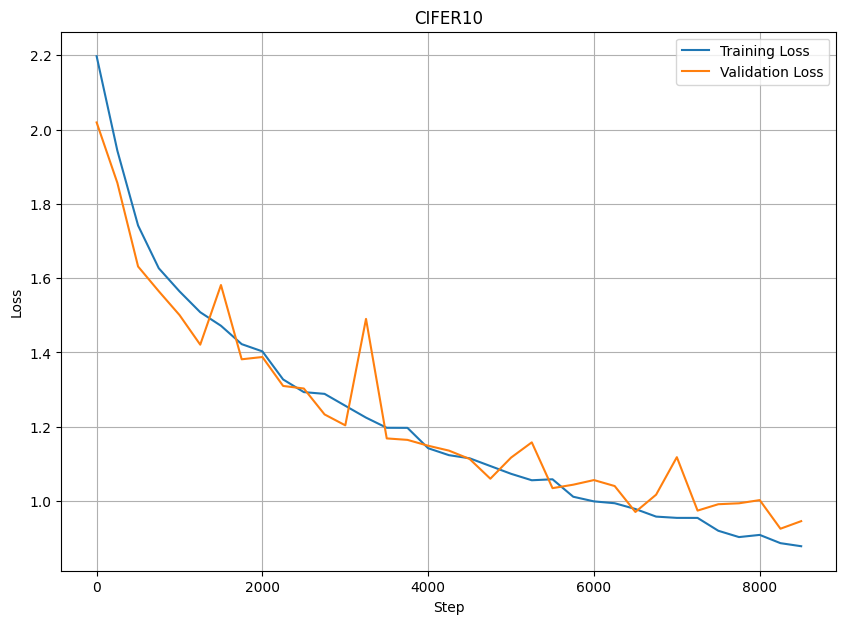

In [20]:
plt.figure(figsize=(10, 7))
steps = [x * logging_interval for x in range(len(train_loss_list))]
plt.plot(steps, train_loss_list, label='Training Loss')
plt.plot(steps, val_loss_list, label='Validation Loss')
plt.title("CIFER10")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Task 8 (20 pts)
You may have noticed that it is quite likely to get overfitting in many cases, preventing it from going beyond 65% accuracy.  

Change the architecture as you like and try to increase the accuracy as much as possible. The base architecture must remain a ConvNet.  
Try any idea that comes to your mind but **justify it**.

Some hints:

- Add Dropout (Any other hyperparameter to tune?)  
- Change activation functions ([GeLU](https://arxiv.org/pdf/1606.08415v3.pdf) is known to work well with images)  
- Make your CNN deeper  
- Add some regularization techniques  
- Change the optimizer  
- Data augmentation  
- Batch normalization  
- …  

#### Points distribution:

- Any successful try (test accuracy increase): 6 points  
- Accuracy on test set ≥ 70% : 7 points  
- Accuracy on test set ≥ 72% : 8 points  
- Accuracy on test set ≥ 73% : 9 points  
- …  
- Accuracy on test set ≥ 78% : 15 points  

To get the remaining 5 points you should be able also justify your choices (e.g., “I used Dropout because … and hence I have increased epochs as I noted …”).  

**Note:** Transfer learning is **not allowed** — otherwise you can complete this exercise easily, and it is not useful for educational purposes.

In [23]:
class Model(nn.Module):
    def __init__(self, channels=3, height=32, width=32, drop_prob1=0.3, drop_prob2=0.4, drop_prob_fc=0.5):
        super().__init__()
        
        conv1 = nn.Conv2d(channels, 32, kernel_size=5, padding=2)
        h_out, w_out = out_dimensions(conv1, height, width)
        pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        h_out, w_out = h_out // 2, w_out // 2
        conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        h_out, w_out = out_dimensions(conv2, h_out, w_out)
        pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        h_out, w_out = h_out // 2, w_out // 2
        dropout1 = nn.Dropout2d(drop_prob1)
        
        conv3 = nn.Conv2d(32, 20, kernel_size=3, padding=1)
        h_out, w_out = out_dimensions(conv3, h_out, w_out)
        pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        h_out, w_out = h_out // 2, w_out // 2
        dropout2 = nn.Dropout2d(drop_prob2)
        
        self.conv_seq = nn.Sequential(conv1, pool1, nn.ReLU(), dropout1, conv2, pool2, nn.ReLU(), dropout2, conv3, pool3, nn.ReLU())
        
        self.fc1 = nn.Linear(20 * h_out * w_out, out_features=120)
        self.fc2 = nn.Linear(120, out_features=10)
        self.dropout_fc = nn.Dropout(drop_prob_fc)
        
        self.dimensions_final = (20, h_out, w_out)
        
    def forward(self, x):
        x = self.conv_seq(x)
        
        n_channels, h, w = self.dimensions_final
        x = x.view(-1, n_channels * h * w)
        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x)
        x = self.fc2(x)
        
        return x

print(Model(3, 32))

# Init
drop_prob1 = 0.2
drop_prob2 = 0.2
drop_prob_fc = 0.2
model = Model(3, 32, drop_prob1=drop_prob1, drop_prob2=drop_prob2, drop_prob_fc=drop_prob_fc)
early_stop = EarlyStopping(patience=7, min_delta=0.01)
learning_rate = 0.035
batch_size = 32
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()
print(model.dimensions_final)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'mps' 
    if torch.backends.mps.is_available() else 'cpu')
model = model.to(DEVICE)
print("Working on", DEVICE)

train_loader = DataLoader(dataset_train, batch_size=batch_size, pin_memory=True, num_workers=2)
validation_loader = DataLoader(dataset_validation, batch_size=len(dataset_validation), pin_memory=True, num_workers=2)
test_loader = DataLoader(dataset_test, batch_size=len(dataset_test), pin_memory=True, num_workers=2)

# Training Loop
n_epochs = 8
logging_interval = 250
model, train_loss_list, train_acc_list, val_loss_list, val_acc_list = fit(model, epochs=n_epochs, logging_interval=logging_interval)

# Final test evaluation
_, test_acc = evaluate_model(model, test_loader, loss_fn)
print(f"\nTest Accuracy: {test_acc:.2f}%")
    

Model(
  (conv_seq): Sequential(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU()
    (3): Dropout2d(p=0.3, inplace=False)
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): ReLU()
    (7): Dropout2d(p=0.4, inplace=False)
    (8): Conv2d(32, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): ReLU()
  )
  (fc1): Linear(in_features=320, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=10, bias=True)
  (dropout_fc): Dropout(p=0.5, inplace=False)
)
(20, 4, 4)
Working on cuda
Epoch 1, Step 250: Training Loss: 2.2514, Training Accuracy: 15.35% | Val Loss: 2.0944, Val Accuracy: 23.44%
Epoch 1, Step 500: Training Loss: 2.0523, Training Accuracy: 26.34% | Val Loss

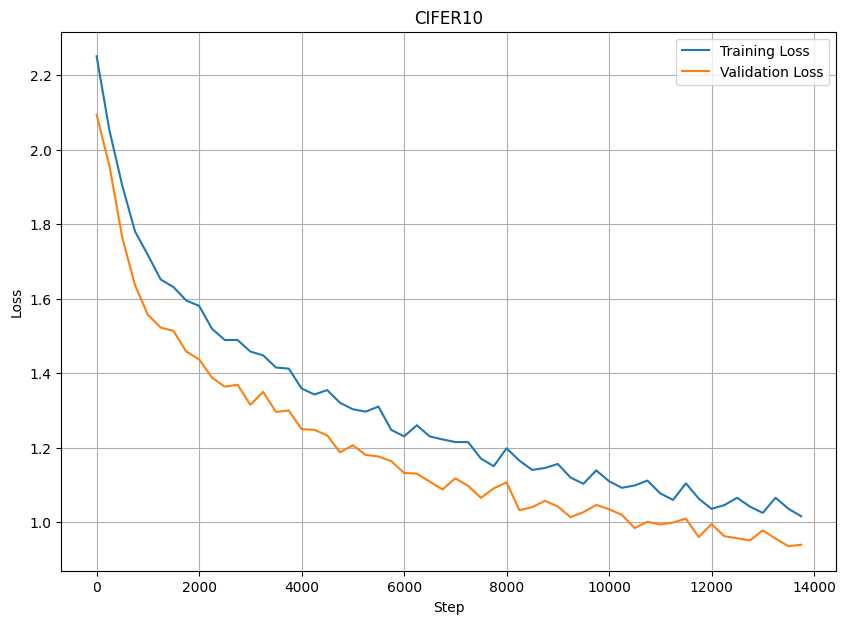

In [24]:
plt.figure(figsize=(10, 7))
steps = [x * logging_interval for x in range(len(train_loss_list))]
plt.plot(steps, train_loss_list, label='Training Loss')
plt.plot(steps, val_loss_list, label='Validation Loss')
plt.title("CIFER10")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Task 9 (10 pts)

Until now, we asked you to keep the seed fixed.  
Train **the model you defined at Task 5** five times with 5 different seeds (already specified below, **don't change them**), each for the same number of epochs epochs.  
Don't change other hyperparameters. Observe the accuracy of the test set in each case. What can you say?  

In [25]:
test_accs = []
for seed in range(5):
    torch.manual_seed(seed)
    print(f"Testing seed {seed}", flush = True)
    
    # init
    model = Model_OG(3, 32)
    early_stop = EarlyStopping(patience=10, min_delta=0.01)
    learning_rate = 0.03
    batch_size = 32
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    loss_fn = nn.CrossEntropyLoss()
    print(model.dimensions_final)

    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'mps' 
        if torch.backends.mps.is_available() else 'cpu')
    model = model.to(DEVICE)
    print("Working on", DEVICE)
    
    # Training loop
    n_epochs = 5
    logging_interval = len(train_loader)
    model,_,_,_,_ = fit(model, logging_interval=logging_interval)

    # Final test evaluation
    _, test_acc = evaluate_model(model, test_loader, loss_fn)
    test_accs.append(test_acc)
    print(f"\nTest Accuracy: {test_acc:.2f}%")

Testing seed 0
(20, 4, 4)
Working on cuda
Epoch 1, Step 1563: Training Loss: 1.7420, Training Accuracy: 36.58% | Val Loss: 1.6563, Val Accuracy: 39.50%
Epoch 2, Step 1563: Training Loss: 1.3239, Training Accuracy: 52.78% | Val Loss: 1.4885, Val Accuracy: 47.40%
Epoch 3, Step 1563: Training Loss: 1.1302, Training Accuracy: 59.79% | Val Loss: 1.3139, Val Accuracy: 55.12%
Epoch 4, Step 1563: Training Loss: 0.9991, Training Accuracy: 64.74% | Val Loss: 1.1113, Val Accuracy: 61.58%
Epoch 5, Step 1563: Training Loss: 0.9037, Training Accuracy: 68.02% | Val Loss: 1.0651, Val Accuracy: 63.88%

Test Accuracy: 64.86%
Testing seed 1
(20, 4, 4)
Working on cuda
Epoch 1, Step 1563: Training Loss: 1.7500, Training Accuracy: 36.04% | Val Loss: 1.4974, Val Accuracy: 45.56%
Epoch 2, Step 1563: Training Loss: 1.3283, Training Accuracy: 52.45% | Val Loss: 1.2574, Val Accuracy: 55.20%
Epoch 3, Step 1563: Training Loss: 1.1342, Training Accuracy: 59.79% | Val Loss: 1.1147, Val Accuracy: 61.00%
Epoch 4, Step

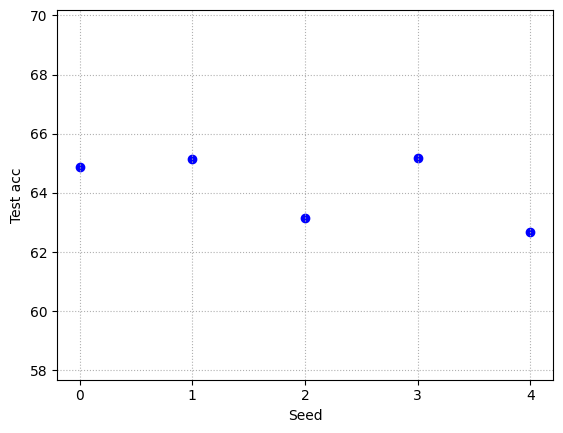

In [26]:
plt.scatter(range(5), test_accs, c="b")
plt.xlabel("Seed")
plt.ylabel("Test acc")
plt.ylim(min(test_accs) - 5, max(test_accs) + 5)
plt.grid(True, ls=':')
plt.xticks(range(5))
plt.show()

## Questions

During the presentation, we may ask questions to ensure you have understood the core concepts of the course. Examples include:
1. Where are the parameters that a CNN learns during training?
2. Why do we use convolutional layers instead of fully connected layers for image data?
3. What is the role of pooling layers? What would happen if we removed them?
4. What is Dropout? Batch Normalizaton? Do you have other regularization tecniques in mind?